In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
#import os
import yfinance as yf # pip install yfinance

In [39]:
#stock_tickers = ["SPY", "QQQ", "IWM", "EFA", "VNQ", "TLT", "GLD"]

#tickers = ["^GSPC", "^NDX", "^IXIC" ] #, "^OMXC25"] OMXC25 fandesikke før 2016!

tickers = ["AIRR","SPY","SCHG","VUG","MGK","XLY","IYW","PSI","FDN","IGM","FTEC","XLK","VGT","SOXX","GLD","XAR","VPU","XLV","PHO","ARKW"]
# calculate simple returns
# def calc_returns(prices: np.ndarray) -> np.ndarray:
#     returns = np.diff(prices) / prices[:-1]
#     return returns
# brug dette i stedet:


data = yf.download(
    tickers,
    #period="1y",
    #interval="1wk",
    start="2010-01-01",
    end="2020-12-31",
    interval="1mo", # defalt er 1d, 1mo, 1wk, 1h, 5m, 15m, 30m, 60m
    auto_adjust=True,
    progress=False
)
                  
#returns = calc_returns(close_prices.values.flatten())


monthly_prices = data["Close"]
monthly_returns = monthly_prices.pct_change()
monthly_returns = monthly_returns.dropna(how="any")
monthly_returns

#weekly_prices = daily_prices.resample("W-FRI").last()#.dropna(how="any")
#weekly_returns = weekly_prices.pct_change()#.dropna(how="any") # denne gøre det samme som calc_returns
#weekly_returns = weekly_returns.dropna(how="any")
#weekly_returns.head()

#https://fred.stlouisfed.org/data/NASDAQ100
#https://fred.stlouisfed.org/data/SP500
#https://fred.stlouisfed.org/data/NASDAQCOM

monthly_returns



Ticker,AIRR,ARKW,FDN,FTEC,GLD,IGM,IYW,MGK,PHO,PSI,SCHG,SOXX,SPY,VGT,VPU,VUG,XAR,XLK,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,
2014-10-01,0.049205,0.017008,0.002299,0.022268,-0.030548,0.011731,0.011417,0.031532,0.051173,0.004993,0.031590,0.006223,0.028336,0.019084,0.092923,0.033135,0.041894,0.020413,0.056326,0.024558
2014-11-01,-0.048312,0.018643,0.018185,0.048256,-0.004882,0.047643,0.051167,0.030879,-0.000774,0.065425,0.030835,0.072174,0.027471,0.049907,0.008084,0.030586,0.032971,0.048101,0.034785,0.054479
2014-12-01,0.000546,-0.008644,-0.013355,-0.014308,0.013112,-0.015932,-0.022747,-0.014431,-0.002711,0.035380,-0.006903,-0.005886,-0.008011,-0.024281,0.025962,-0.013327,0.016658,-0.026830,-0.017670,0.004735
2015-01-01,-0.088347,-0.002922,-0.019406,-0.032321,0.086899,-0.034205,-0.035314,-0.014150,-0.050619,-0.007569,-0.010516,-0.040955,-0.024273,-0.035126,0.021789,-0.011423,-0.014981,-0.030047,0.016766,-0.025916
2015-02-01,0.107115,0.082560,0.099784,0.082788,-0.059052,0.083749,0.083798,0.062656,0.039738,0.082632,0.065545,0.096074,0.056205,0.083325,-0.059381,0.062451,0.086459,0.079950,0.042876,0.085441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-08-01,0.093636,0.130465,0.079204,0.112474,-0.003236,0.098459,0.116170,0.113787,0.016183,-0.005922,0.097998,0.057956,0.069797,0.111356,-0.025411,0.100934,0.056419,0.118808,0.025870,0.095547
2020-09-01,-0.049612,-0.034409,-0.050708,-0.051221,-0.041714,-0.055498,-0.056739,-0.054371,0.003033,-0.039096,-0.041129,-0.008496,-0.041281,-0.050891,-0.001161,-0.048890,-0.034277,-0.055443,-0.025679,-0.020721
2020-10-01,0.033030,0.020350,-0.007009,-0.040880,-0.005194,-0.026006,-0.026286,-0.032836,0.028410,0.037665,-0.026895,0.006483,-0.021031,-0.040976,0.056214,-0.028245,-0.024423,-0.047939,-0.032383,-0.025210


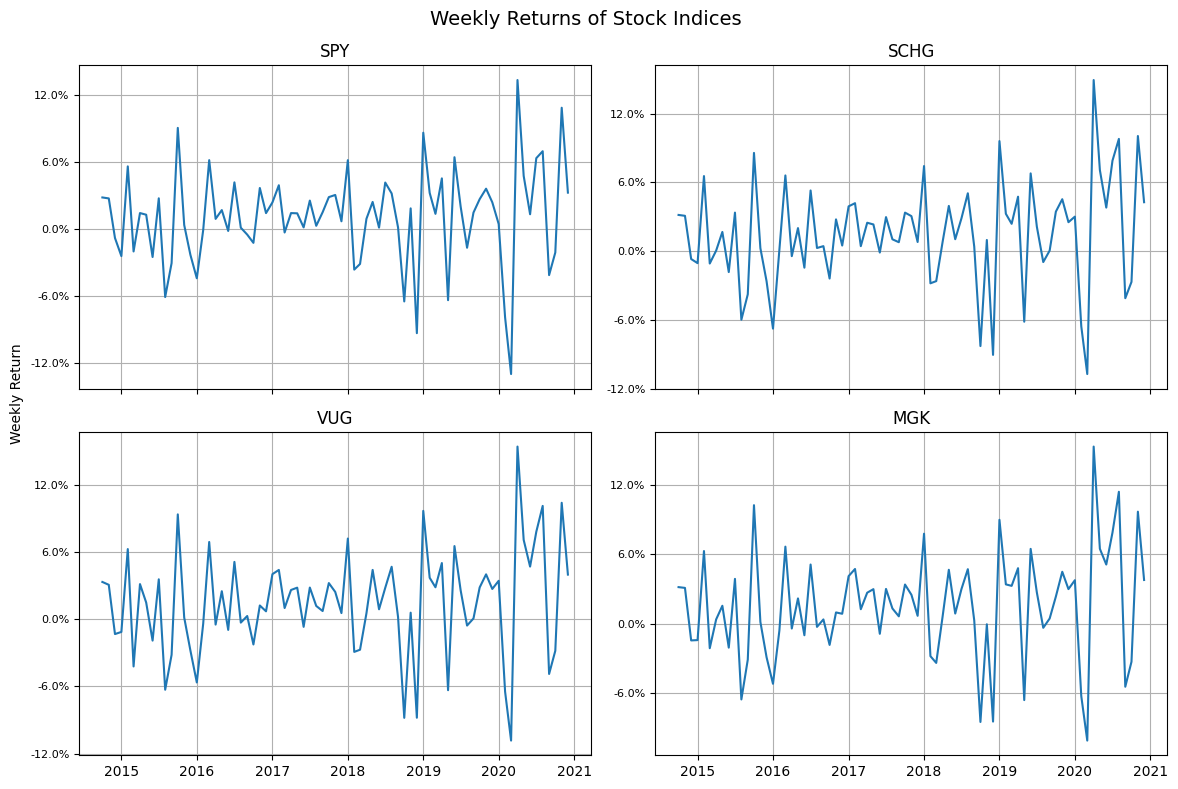

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.flatten()

for i, ticker in enumerate(tickers[1:5]):  # plot the first 4 tickers for better visibility
    axes[i].plot(monthly_returns.index, monthly_returns[ticker])
    axes[i].set_title(ticker)
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(5))
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1%}"))
    axes[i].tick_params(axis='y', labelsize=8)
    axes[i].grid()

fig.suptitle("Weekly Returns of Stock Indices", fontsize=14)
fig.supylabel("Weekly Return", fontsize=10)  # single shared y label
plt.tight_layout()
plt.show()

In [41]:
monthly_returns["AIRR"].describe(), monthly_returns["SPY"].describe(), monthly_returns["SCHG"].describe()

(count    75.000000
 mean      0.010783
 std       0.068162
 min      -0.214659
 25%      -0.037226
 50%       0.013018
 75%       0.045597
 max       0.181273
 Name: AIRR, dtype: float64,
 count    75.000000
 mean      0.011162
 std       0.043373
 min      -0.129987
 25%      -0.006490
 50%       0.014294
 75%       0.032168
 max       0.133611
 Name: SPY, dtype: float64,
 count    75.000000
 mean      0.014757
 std       0.045830
 min      -0.107363
 25%      -0.008229
 50%       0.016738
 75%       0.038557
 max       0.149429
 Name: SCHG, dtype: float64)

In [42]:
R = monthly_returns.to_numpy()
T, n = R.shape
print(f"Shape of R: {R.shape}")
mu_assets = R.mean(axis=0)  
print(f"Mean returns (mu_assets): {mu_assets}")
sigma_assets = R.std(axis=0, ddof=1)
print(f"Standard deviations (sigma_assets): {sigma_assets}")

#p = np.ones(T) / T 



Shape of R: (75, 20)
Mean returns (mu_assets): [0.01078341 0.03253531 0.01826089 0.01909959 0.00654183 0.01906096
 0.01859096 0.01494064 0.00996465 0.02358371 0.01475748 0.02307964
 0.01116229 0.01933947 0.00884703 0.0146048  0.01402911 0.01851027
 0.0099553  0.0142636 ]
Standard deviations (sigma_assets): [0.06816216 0.08384231 0.05528278 0.05342004 0.04092623 0.05259575
 0.05337643 0.04658958 0.04594073 0.07236489 0.04582967 0.0656083
 0.04337277 0.05350967 0.04028714 0.04680295 0.06193737 0.05155902
 0.04231911 0.05120408]


In [43]:
R[1:5, :5]  # print the first 4 rows and 4 columns of R for verification    

array([[-0.04831171,  0.01864252,  0.01818481,  0.04825555, -0.00488197],
       [ 0.00054555, -0.00864357, -0.01335482, -0.0143081 ,  0.01311213],
       [-0.08834658, -0.00292248, -0.01940637, -0.03232109,  0.08689906],
       [ 0.1071153 ,  0.08255957,  0.09978374,  0.08278809, -0.05905219]])

In [44]:
# save R into CSV file

path = "monthly_returns.csv"
monthly_returns.to_csv(path, index=True)

print(f"monthly_returns{tickers}.csv")

monthly_returns['AIRR', 'SPY', 'SCHG', 'VUG', 'MGK', 'XLY', 'IYW', 'PSI', 'FDN', 'IGM', 'FTEC', 'XLK', 'VGT', 'SOXX', 'GLD', 'XAR', 'VPU', 'XLV', 'PHO', 'ARKW'].csv


In [45]:
monthly_returns["SPY"]

Date
2014-10-01    0.028336
2014-11-01    0.027471
2014-12-01   -0.008011
2015-01-01   -0.024273
2015-02-01    0.056205
                ...   
2020-08-01    0.069797
2020-09-01   -0.041281
2020-10-01   -0.021031
2020-11-01    0.108777
2020-12-01    0.032646
Freq: MS, Name: SPY, Length: 75, dtype: float64